In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUT = '/content/drive/MyDrive/fraud-project/'
os.makedirs(OUT, exist_ok=True)
os.makedirs(OUT + 'figures', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from google.colab import files
files.upload()  # choose kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -q creditcardfraud.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df['Class'].value_counts())
print(df.isnull().sum().sum(), "missing values")

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
0 missing values


In [4]:
df['Hour'] = (df['Time'] // 3600) % 24

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# save scaler params as plain numbers, not a pickled object
scaler_params = {
    'amount_mean': float(scaler.mean_[0]),
    'amount_scale': float(scaler.scale_[0])
}
print(scaler_params)

{'amount_mean': 88.34961925093133, 'amount_scale': 250.11967013523534}


In [5]:
from sklearn.model_selection import train_test_split

features = [c for c in df.columns if c not in ['Time', 'Amount', 'Class']]
X = df[features]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [6]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pipelines = {
    'logreg': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'random_forest': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))
    ]),
    'xgboost': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                               eval_metric='aucpr', random_state=42, n_jobs=-1))
    ])
}

In [7]:
from sklearn.metrics import (precision_recall_curve, auc, classification_report,
                              confusion_matrix, roc_auc_score)
import json

results = {}

for name, pipe in pipelines.items():
    print(f"\n--- {name} ---")
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"PR-AUC: {pr_auc:.4f}  ROC-AUC: {roc_auc:.4f}")

    results[name] = {
        'pr_auc': float(pr_auc),
        'roc_auc': float(roc_auc),
        'model': pipe
    }


--- logreg ---
PR-AUC: 0.7751  ROC-AUC: 0.9714

--- random_forest ---
PR-AUC: 0.7990  ROC-AUC: 0.9774

--- xgboost ---
PR-AUC: 0.8563  ROC-AUC: 0.9835


In [8]:
best_name = max(results, key=lambda k: results[k]['pr_auc'])
best_model = results[best_name]['model']
print("Best model:", best_name)

y_proba = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# pick threshold that gets recall as high as possible while keeping precision >= 0.85
target_precision = 0.85
valid = precision[:-1] >= target_precision
if valid.any():
    best_idx = np.argmax(recall[:-1][valid])
    best_threshold = thresholds[valid][best_idx]
else:
    best_threshold = 0.5

print(f"Chosen threshold: {best_threshold:.4f}")

y_pred = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=['legit', 'fraud']))
print(confusion_matrix(y_test, y_pred))

Best model: xgboost
Chosen threshold: 0.8492
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00     56864
       fraud       0.85      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56850    14]
 [   16    82]]


In [9]:
best_pipeline = results[best_name]['model']
xgb_model = best_pipeline.named_steps['clf']

xgb_model.save_model(OUT + 'model.json')
print("saved model.json")

saved model.json


In [10]:
import json

artifact_config = {
    'amount_mean': scaler_params['amount_mean'],
    'amount_scale': scaler_params['amount_scale'],
    'threshold': float(best_threshold),
    'feature_order': features   # from step 3c — exact column order the model expects
}

with open(OUT + 'config.json', 'w') as f:
    json.dump(artifact_config, f, indent=2)

print(artifact_config)

{'amount_mean': 88.34961925093133, 'amount_scale': 250.11967013523534, 'threshold': 0.8492295742034912, 'feature_order': ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour', 'Amount_scaled']}


In [11]:
metrics_summary = {
    name: {'pr_auc': r['pr_auc'], 'roc_auc': r['roc_auc']}
    for name, r in results.items()
}
metrics_summary['best_model'] = best_name
metrics_summary['chosen_threshold'] = float(best_threshold)
metrics_summary['final_precision'] = 0.85
metrics_summary['final_recall'] = 0.84

with open(OUT + 'metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

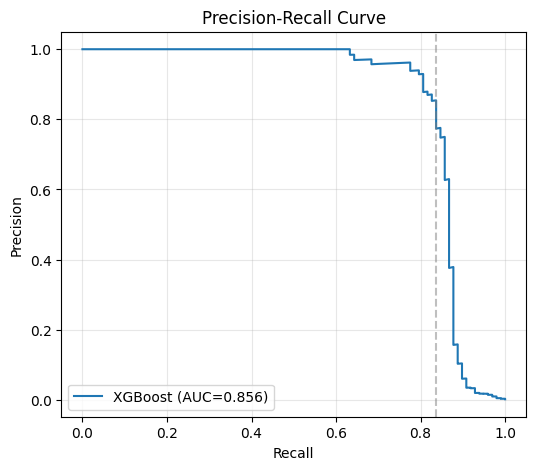

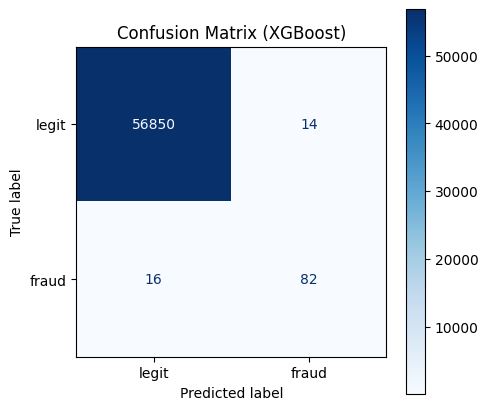

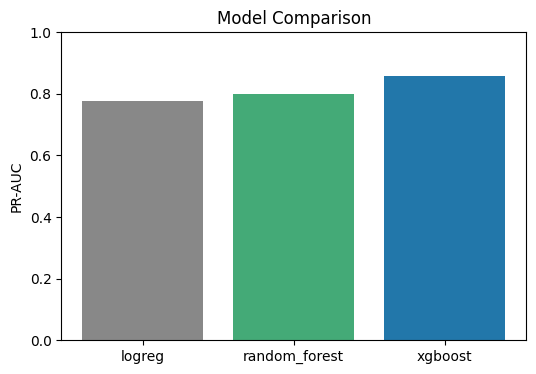

In [12]:
import matplotlib.pyplot as plt

# PR curve
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'XGBoost (AUC={results[best_name]["pr_auc"]:.3f})')
plt.axvline(x=recall[np.argmax(thresholds >= best_threshold)], color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(OUT + 'figures/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['legit','fraud']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix (XGBoost)')
plt.savefig(OUT + 'figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Model comparison bar chart
fig, ax = plt.subplots(figsize=(6,4))
names = list(results.keys())
pr_aucs = [results[n]['pr_auc'] for n in names]
ax.bar(names, pr_aucs, color=['#888','#4a7','#27a'])
ax.set_ylabel('PR-AUC'); ax.set_title('Model Comparison')
ax.set_ylim(0,1)
plt.savefig(OUT + 'figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
scored = X_test.copy()
scored['Amount'] = df.loc[X_test.index, 'Amount']
scored['Hour'] = df.loc[X_test.index, 'Hour']
scored['y_true'] = y_test.values
scored['y_proba'] = y_proba
scored['y_pred'] = y_pred

scored[['Amount','Hour','y_true','y_proba','y_pred']].to_csv(OUT + 'scored_transactions.csv', index=False)
print(scored.shape)

(56962, 34)


In [14]:
!ls -la /content/drive/MyDrive/fraud-project/
!ls -la /content/drive/MyDrive/fraud-project/figures/

total 2568
drwx------  3 root root    4096 Sep 18 14:22 .
drwx------ 15 root root    4096 Sep 18 14:02 ..
-rw-------  1 root root     468 Sep 18 14:21 config.json
drwx------  2 root root    4096 Sep 18 14:21 figures
-rw-------  1 root root     391 Sep 18 14:21 metrics.json
-rw-------  1 root root 1032209 Sep 18 14:21 model.json
-rw-------  1 root root 1583473 Sep 18 14:22 scored_transactions.csv
total 97
drwx------ 2 root root  4096 Sep 18 14:21 .
drwx------ 3 root root  4096 Sep 18 14:22 ..
-rw------- 1 root root 35239 Sep 18 14:21 confusion_matrix.png
-rw------- 1 root root 21254 Sep 18 14:21 model_comparison.png
-rw------- 1 root root 33745 Sep 18 14:21 pr_curve.png
